Name: Lin Qizhou

Key insights / takeaways:
- I wrote an agent prompt for a local Qwen 3B smolagents workflow to autonomously download the last 180 days of daily close prices for two portfolios: Big Tech (NVDA, AAPL, MSFT) and Big Banks (JPM, BAC, C).
- The agent computes daily returns and Sharpe ratios for each ticker using a zero risk-free rate assumption, then summarizes which sector performs better on a risk-adjusted basis via average Sharpe comparison.
- The agent produces a visualization artifact by saving a sector-colored Sharpe ratio bar chart as `sharpe_comparison.png`, along with a ranked results table for transparency.

# Working with a local LLM


In this notebook, we explore the power and advantages of running Large Language Models (LLMs) locally. While cloud-based proprietary LLMs offer convenience, they often come with significant costs, strict rate limits, and potential privacy concerns due to data being processed on external servers. By leveraging local LLMs, we gain full control over our data, ensure privacy, and eliminate ongoing API costs and rate limitations, making them an excellent choice for research, development, and applications requiring sensitive data handling. Here, we'll be working with a local Code Agent.

#The Local "Code Agent" (Qwen 2.5-Coder-3B-Instruct)
⚠️ **Important Colab Note: Ensure your runtime is set to T4 GPU (Runtime > Change runtime type > T4 GPU). This model fits tightly in the 16GB VRAM, so do not run other large models in the same session.**

Before we can run our local Code Agent, we need to install the necessary Python libraries. `smolagents` is our framework for building agents, while `transformers`, `accelerate`, and `bitsandbytes` are crucial for efficiently loading and running large language models on a GPU. `yfinance`, `seaborn`, and `matplotlib` are data science libraries the agent will use for financial data analysis and visualization.

In [1]:
# ==========================================
# Install Dependencies
# ==========================================
# We need 'accelerate' and 'bitsandbytes' to load the model efficiently on the GPU.
# Added 'duckduckgo_search' to enable web search capabilities for the agent.
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib duckduckgo_search


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 135.4 MB/s eta 0:00:00


Now we'll load the `Qwen 2.5 Coder 3B` model. This model is specifically designed for code generation tasks. We're using `TransformersModel` from `smolagents` to load it. `device_map='auto'` ensures the model automatically utilizes the available T4 GPU, and `torch_dtype=torch.float16` reduces memory footprint by using half-precision floating-point numbers. `max_new_tokens` is set to allow for longer code outputs.

In [2]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

# We use the 3B-Instruct model.
# device_map="auto" finds the Colab GPU.
# torch_dtype=torch.float16 cuts memory usage in half.
model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048  # Give it space to write longer scripts
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


With the model loaded, we can now initialize our `CodeAgent`. We provide it with the loaded `model` and specify `additional_authorized_imports`. This list tells the agent which Python libraries it is allowed to use when generating and executing code. Crucially, we don't give it predefined tools; instead, it writes its own code using these authorized libraries, making it highly flexible.

In [3]:
# ==========================================
# Initialize the Agent
# ==========================================

# We authorize the agent to use specific data science libraries, and now also a web search library.
agent = CodeAgent(
    tools=[], # We don't need pre-made tools; the agent writes its own code.
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot",
        "duckduckgo_search" # Added for web search capabilities
    ]
)


#Coding task
*Download data for BTC-USD, ETH-USD, and SOL-USD for the last 90 days. Calculate the correlation matrix and plot it as a heatmap.*

Here, we're giving the `CodeAgent` a multi-step task to perform. It involves downloading financial data for cryptocurrencies using `yfinance`, calculating correlations, and then visualizing the results as a heatmap using `seaborn`. The agent will interpret this prompt, write the Python code, and then execute it to produce the `crypto_heatmap.png` file.

🤖 Agent is coding... (Watch the 'Thought' process below)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days using yfinance.     │
│ 2. Create a single DataFrame with these close prices.                                                           │
│ 3. Calculate the correlation matrix of the returns.                                                             │
│ 4. Plot this correlation matrix as a heatmap using seaborn with annotations.                                    │
│ 5. Save the plot as 'crypto_heatmap.png'.                                                                       │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
                                                                                                                   
  # List of cryptocurrencies                                                                                       
  cryptos = ['BTC-USD', 'ETH-USD', 'SOL-USD']                                                                      
                                                                                                                   
  # Download daily closing prices for the last 30 days                                                             
  data = yf.download(cryptos, period='30d')['Close']                                                               
                                                                                                                   
  import pandas as pd                                                                                              
                                                                                                                   
  # Create a DataFrame with the close prices                                                                       
  df_close = pd.DataFrame(data, columns=['BTC-USD', 'ETH-USD', 'SOL-USD'])                                         
                                                                                                                   
  # Calculate the daily returns                                                                                    
  returns = df_close.pct_change()                                                                                  
                                                                                                                   
  # Calculate the correlation matrix of the returns                                                                
  correlation_matrix = returns.corr()                                                                              
                                                                                                                   
  import seaborn as sns                                                                                            
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Create a heatmap of the correlation matrix                                                                     
  plt.figure(figsize=(10, 8))                                                                                      
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")                                          
  plt.title('Correlation Matrix of Crypto Returns')                                                                
  plt.savefig('crypto_heatmap.png')                                                                                
  plt.show()                                                                                                       
                                                                                                                   
  final_answer('crypto_heatmap.png')                                                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed


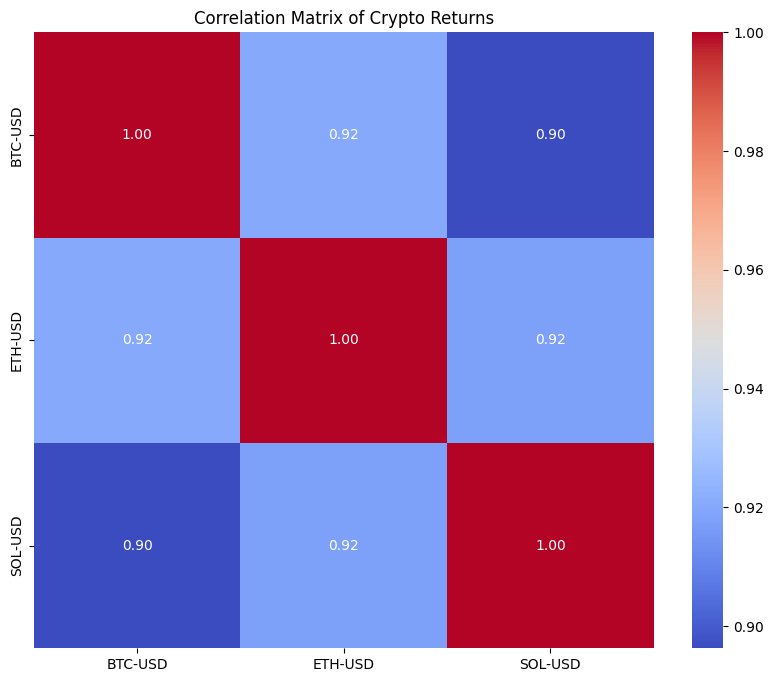

Final answer: crypto_heatmap.png

[Step 1: Duration 32.59 seconds| Input tokens: 2,132 | Output tokens: 406]

In [4]:
# ==========================================
# Execute the Crypto Heatmap Task
# ==========================================
# We give it a complex multi-step instruction.
task_prompt = """
1. Download daily closing data for 'BTC-USD', 'ETH-USD', and 'SOL-USD' for the last 30 days using yfinance.
2. Create a single DataFrame with these close prices.
3. Calculate the correlation matrix of the returns.
4. Plot this correlation matrix as a heatmap using seaborn with annotations.
5. Save the plot as 'crypto_heatmap.png'.
"""

print("🤖 Agent is coding... (Watch the 'Thought' process below)")
result = agent.run(task_prompt,stream=False)

In [5]:
print(result)

crypto_heatmap.png


After the agent has attempted to generate and save the heatmap, this code block checks if the `crypto_heatmap.png` file exists. If it does, it uses `IPython.display` to show the generated image directly within the Colab output. This allows us to visually inspect the agent's output.


📊 Displaying Generated Heatmap:


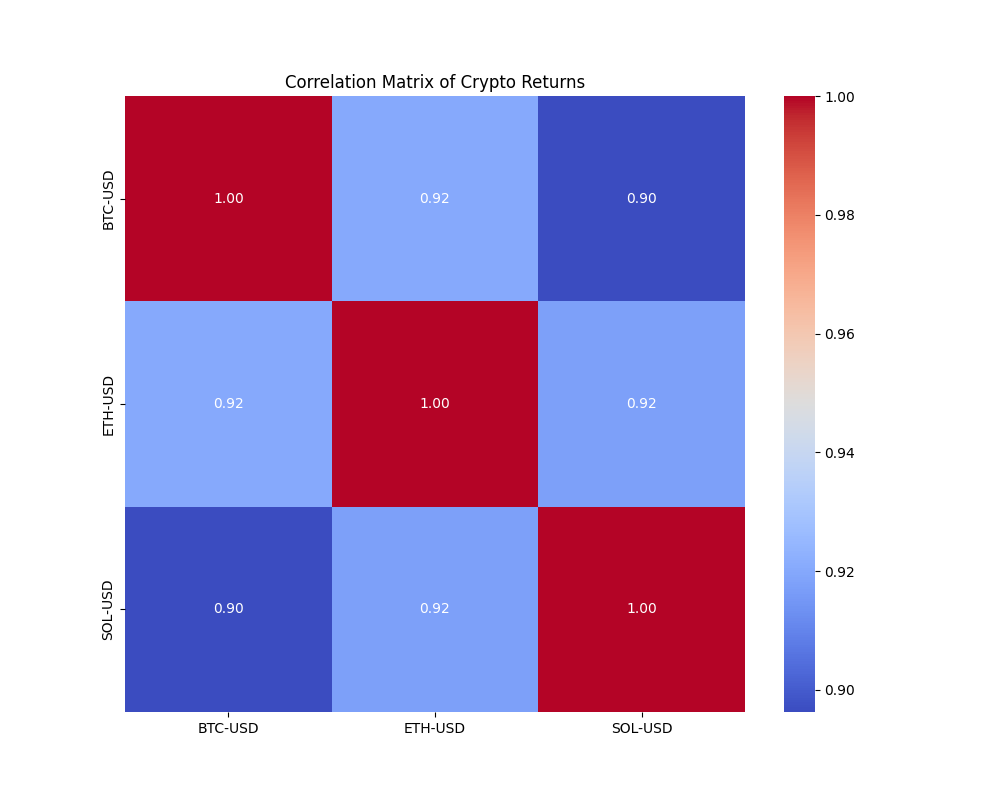

In [6]:
# ==========================================
# Display the Result
# ==========================================
import IPython
import os

if os.path.exists("crypto_heatmap.png"):
    print("\n📊 Displaying Generated Heatmap:")
    IPython.display.display(IPython.display.Image("crypto_heatmap.png"))
else:
    print("⚠️ No image file found. Check the agent's output logs above for errors.")

#Let's replicate previous tasks with the local LLM


This task demonstrates the agent's ability to perform data analysis using `pandas`. We ask it to fetch historical stock data for NVIDIA (`NVDA`), calculate the daily percentage returns, and then determine the standard deviation (volatility) of these returns. The agent will write the necessary `yfinance` and `pandas` code to achieve this.

In [7]:
# The "Pandas" Task
# We ask for a calculation that requires fetching data and doing math.

task = """
Get the historical closing prices for 'NVDA' for the last 1 month.
Calculate the standard deviation of the daily percentage returns (volatility).
Print the volatility as a percentage.
"""

result=agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Get the historical closing prices for 'NVDA' for the last 1 month.                                              │
│ Calculate the standard deviation of the daily percentage returns (volatility).                                  │
│ Print the volatility as a percentage.                                                                           │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
                                                                                                                   
  # Step 1: Fetch historical closing prices for NVDA for the last month                                            
  nvda = yf.Ticker('NVDA')                                                                                         
  data = nvda.history(period='1mo')                                                                                
                                                                                                                   
  # Step 2: Calculate the daily percentage returns                                                                 
  data['Return'] = data['Close'].pct_change()                                                                      
                                                                                                                   
  # Step 3: Compute the standard deviation of the daily percentage returns                                         
  volatility = data['Return'].std()                                                                                
                                                                                                                   
  # Step 4: Convert the standard deviation to a percentage                                                         
  volatility_percentage = volatility * 100                                                                         
                                                                                                                   
  # Step 5: Print the volatility as a percentage                                                                   
  print(f"Volatility of NVDA over the last month: {volatility_percentage:.2f}%")                                   
                                                                                                                   
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
                                                                                                                   
  # Step 1: Fetch historical closing prices for NVDA for the last month                                            
  nvda = yf.Ticker('NVDA')                                                                                         
  data = nvda.history(period='1mo')                                                                                
                                                                                                                   
  # Step 2: Calculate the daily percentage returns                                                                 
  data['Return'] = data['Close'].pct_change()                                                                      
                                                                                                                   
  # Step 3: Compute the standard deviation of the daily percentage returns                                         
  volatility = data['Return'].std()                                                                                
                                                         

Execution logs:
Volatility of NVDA over the last month: 2.31%
Volatility of NVDA over the last month: 2.31%

Out: None

[Step 1: Duration 28.06 seconds| Input tokens: 2,087 | Output tokens: 443]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
                                                                                                                   
  # Step 1: Fetch historical closing prices for NVDA for the last month                                            
  nvda = yf.Ticker('NVDA')                                                                                         
  data = nvda.history(period='1mo')                                                                                
                                                                                                                   
  # Step 2: Calculate the daily percentage returns                                                                 
  data['Return'] = data['Close'].pct_change()                                                                      
                                                                                                                   
  # Step 3: Compute the standard deviation of the daily percentage returns                                         
  volatility = data['Return'].std()                                                                                
                                                                                                                   
  # Step 4: Convert the standard deviation to a percentage                                                         
  volatility_percentage = volatility * 100                                                                         
                                                                                                                   
  # Step 5: Print the volatility as a percentage                                                                   
  print(f"Volatility of NVDA over the last month: {volatility_percentage:.2f}%")                                   
                                                                                                                   
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
                                                                                                                   
  # Step 1: Fetch historical closing prices for NVDA for the last month                                            
  nvda = yf.Ticker('NVDA')                                                                                         
  data = nvda.history(period='1mo')                                                                                
                                                                                                                   
  # Step 2: Calculate the daily percentage returns                                                                 
  data['Return'] = data['Close'].pct_change()                                                                      
                                                                                                                   
  # Step 3: Compute the standard deviation of the daily percentage returns                                         
  volatility = data['Return'].std()                                                                                
                                                         

Execution logs:
Volatility of NVDA over the last month: 2.31%
Volatility of NVDA over the last month: 2.31%

Out: None

[Step 3: Duration 65.30 seconds| Input tokens: 8,865 | Output tokens: 1,982]

Reached max steps.

[Step 4: Duration 3.41 seconds| Input tokens: 11,546 | Output tokens: 1,999]

In [8]:
print(result)

Volatility of NVDA over the last month: 2.31%


In this visual task, the agent is instructed to fetch Bitcoin (BTC-USD) closing prices, calculate a 7-day moving average, and then plot both on a chart using `matplotlib`. The goal is to see if the agent can generate a complete visualization and save it as an image file (`btc_chart.png`). A helper snippet is included to display the image if the agent doesn't do so automatically.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Plot the closing price of Bitcoin (BTC-USD) for the last 3 months.                                              │
│ Add a 7-day moving average line to the chart.                                                                   │
│ Save the chart as 'btc_chart.png' and display it.                                                               │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
  from datetime import datetime, timedelta                                                                         
                                                                                                                   
  # Fetch historical data for Bitcoin (BTC-USD) for the last 3 months                                              
  end_date = datetime.now()                                                                                        
  start_date = end_date - timedelta(days=90)                                                                       
  btc_data = yf.download('BTC-USD', start=start_date, end=end_date)                                                
                                                                                                                   
  # Plotting the closing price of Bitcoin                                                                          
  plt.figure(figsize=(14, 7))                                                                                      
  plt.plot(btc_data['Close'], label='Bitcoin Closing Price')                                                       
                                                                                                                   
  # Adding a 7-day moving average line                                                                             
  btc_data['7-Day MA'] = btc_data['Close'].rolling(window=7).mean()                                                
  plt.plot(btc_data['7-Day MA'], label='7-Day Moving Average')                                                     
                                                                                                                   
  # Adding labels and title                                                                                        
  plt.xlabel('Date')                                                                                               
  plt.ylabel('Price (USD)')                                                                                        
  plt.title('Bitcoin Closing Price with 7-Day Moving Average')                                                     
  plt.legend()                                                                                                     
                                                                                                                   
  # Saving the chart as 'btc_chart.png'                                                                            
  plt.savefig('btc_chart.png')                                                                                     
                                                                                                                   
  # Displaying the chart                                                                                           
  plt.show()                                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


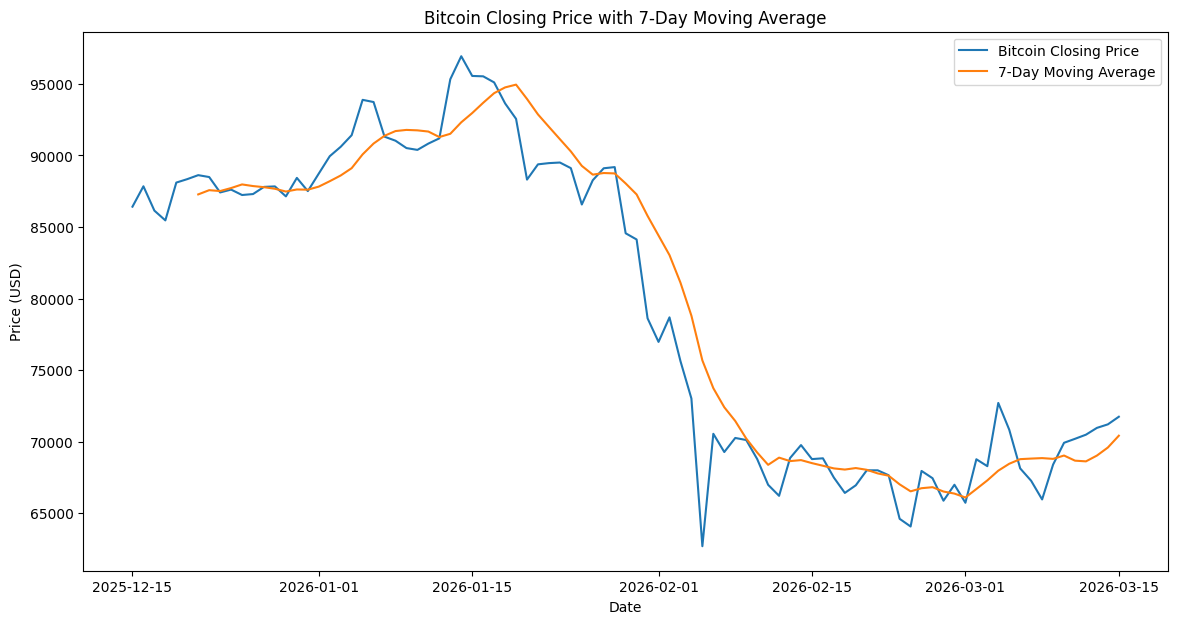

Out: None

[Step 1: Duration 21.52 seconds| Input tokens: 2,093 | Output tokens: 324]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
  from datetime import datetime, timedelta                                                                         
                                                                                                                   
  # Fetch historical data for Bitcoin (BTC-USD) for the last 3 months                                              
  end_date = datetime.now()                                                                                        
  start_date = end_date - timedelta(days=90)                                                                       
  btc_data = yf.download('BTC-USD', start=start_date, end=end_date)                                                
                                                                                                                   
  # Plotting the closing price of Bitcoin                                                                          
  plt.figure(figsize=(14, 7))                                                                                      
  plt.plot(btc_data['Close'], label='Bitcoin Closing Price')                                                       
                                                                                                                   
  # Adding a 7-day moving average line                                                                             
  btc_data['7-Day MA'] = btc_data['Close'].rolling(window=7).mean()                                                
  plt.plot(btc_data['7-Day MA'], label='7-Day Moving Average')                                                     
                                                                                                                   
  # Adding labels and title                                                                                        
  plt.xlabel('Date')                                                                                               
  plt.ylabel('Price (USD)')                                                                                        
  plt.title('Bitcoin Closing Price with 7-Day Moving Average')                                                     
  plt.legend()                                                                                                     
                                                                                                                   
  # Saving the chart as 'btc_chart.png'                                                                            
  plt.savefig('btc_chart.png')                                                                                     
                                                                                                                   
  # Displaying the chart                                                                                           
  plt.show()                                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


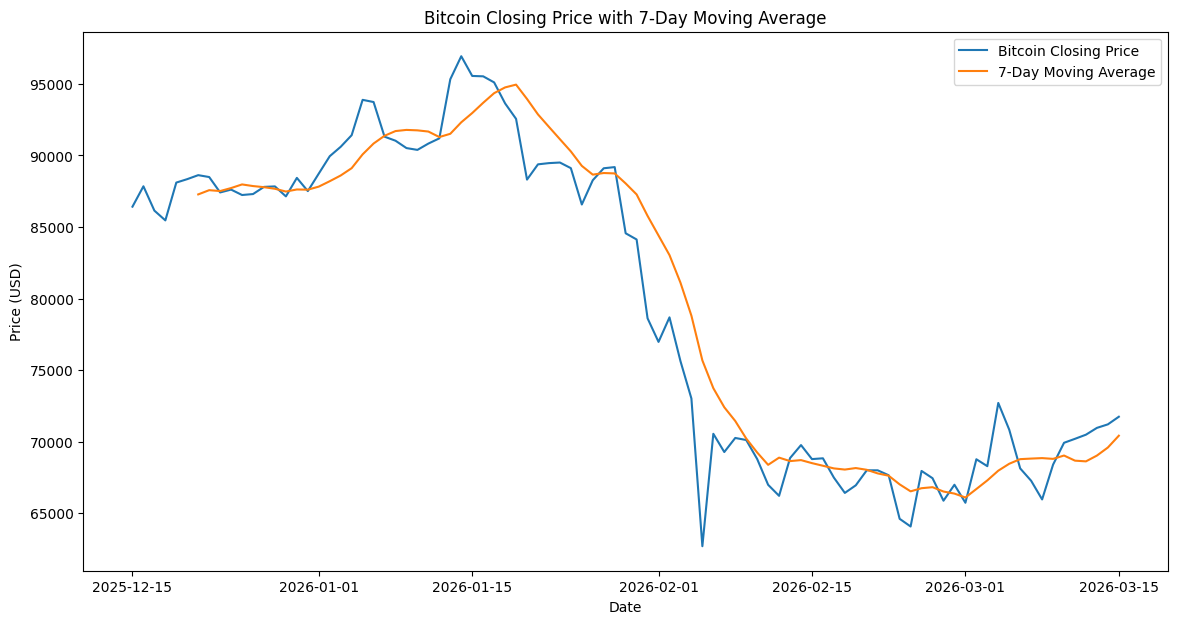

Out: None

[Step 2: Duration 37.28 seconds| Input tokens: 4,778 | Output tokens: 850]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
  from datetime import datetime, timedelta                                                                         
                                                                                                                   
  # Fetch historical data for Bitcoin (BTC-USD) for the last 3 months                                              
  end_date = datetime.now()                                                                                        
  start_date = end_date - timedelta(days=90)                                                                       
  btc_data = yf.download('BTC-USD', start=start_date, end=end_date)                                                
                                                                                                                   
  # Plotting the closing price of Bitcoin                                                                          
  plt.figure(figsize=(14, 7))                                                                                      
  plt.plot(btc_data['Close'], label='Bitcoin Closing Price')                                                       
                                                                                                                   
  # Adding a 7-day moving average line                                                                             
  btc_data['7-Day MA'] = btc_data['Close'].rolling(window=7).mean()                                                
  plt.plot(btc_data['7-Day MA'], label='7-Day Moving Average')                                                     
                                                                                                                   
  # Adding labels and title                                                                                        
  plt.xlabel('Date')                                                                                               
  plt.ylabel('Price (USD)')                                                                                        
  plt.title('Bitcoin Closing Price with 7-Day Moving Average')                                                     
  plt.legend()                                                                                                     
                                                                                                                   
  # Saving the chart as 'btc_chart.png'                                                                            
  plt.savefig('btc_chart.png')                                                                                     
                                                                                                                   
  # Displaying the chart                                                                                           
  plt.show()                                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


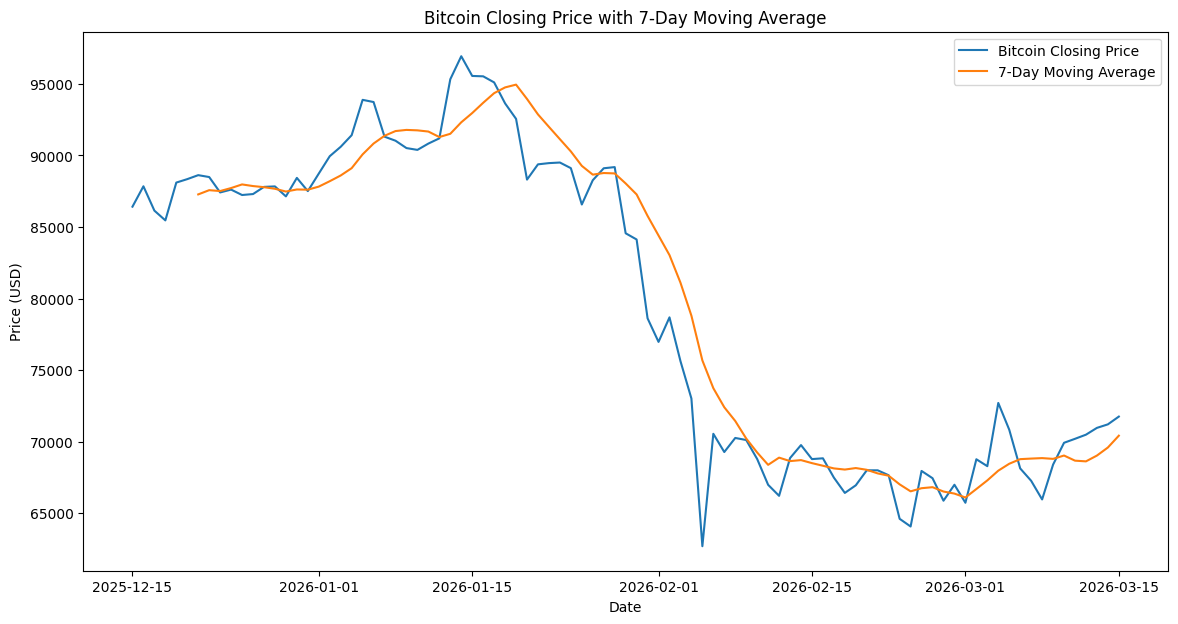

Out: None

[Step 3: Duration 41.10 seconds| Input tokens: 8,011 | Output tokens: 1,376]

Reached max steps.

[Step 4: Duration 4.51 seconds| Input tokens: 9,851 | Output tokens: 1,424]

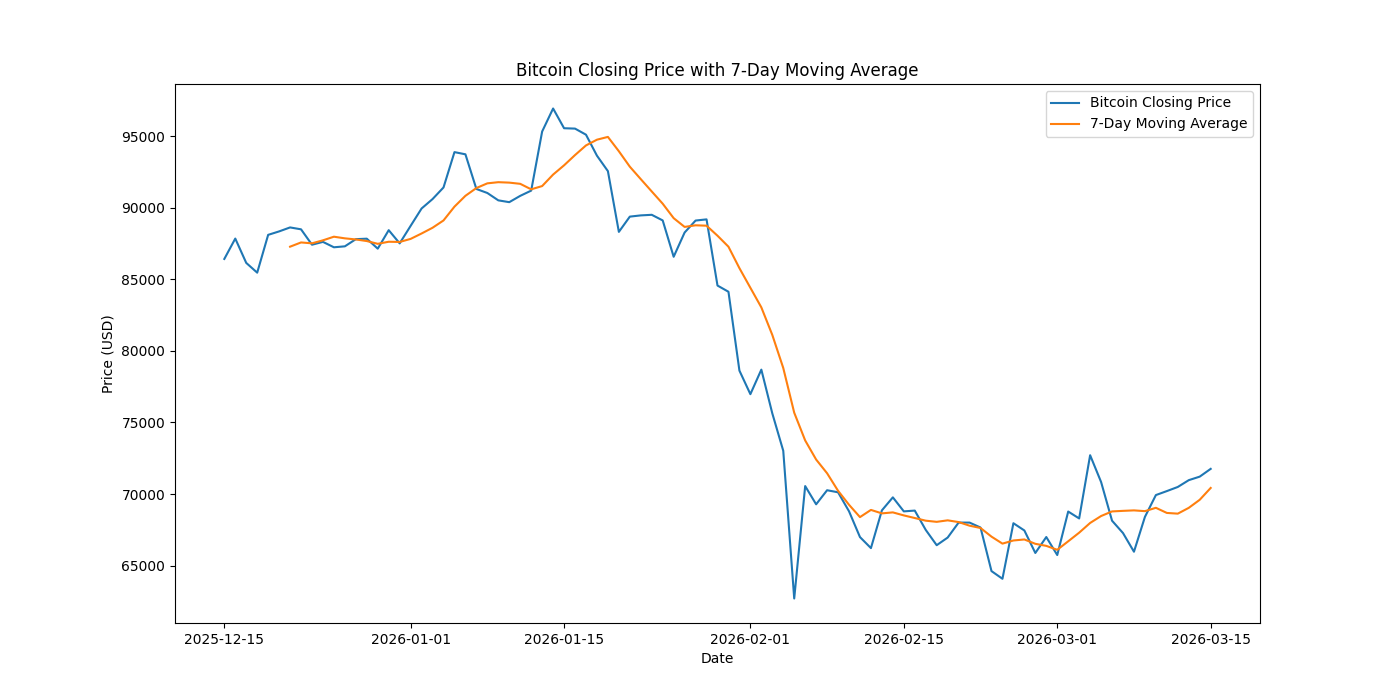

In [9]:
# The "Visual" Task
# The agent will use matplotlib to create a chart.

task_viz = """
Plot the closing price of Bitcoin (BTC-USD) for the last 3 months.
Add a 7-day moving average line to the chart.
Save the chart as 'btc_chart.png' and display it.
"""

agent.run(task_viz)

# Helper to show the image in Colab if the agent doesn't auto-display
import IPython
if os.path.exists("btc_chart.png"):
    IPython.display.display(IPython.display.Image("btc_chart.png"))

This task challenges the agent to act as a technical analyst. It needs to calculate the Relative Strength Index (RSI), a common momentum indicator, for Apple stock (`AAPL`) over a 14-day period. Based on the calculated RSI value, it should then determine if the stock is 'Overbought' or 'Oversold' according to standard thresholds.

In [10]:
# The Technical Analyst Task
task = """
Prompt: Calculate the Relative Strength Index (RSI) for Apple stock over the
last 14 days and tell me if it is currently 'Overbought' (>70) or 'Oversold' (<30).
"""

result = agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Prompt: Calculate the Relative Strength Index (RSI) for Apple stock over the                                    │
│ last 14 days and tell me if it is currently 'Overbought' (>70) or 'Oversold' (<30).                             │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
                                                                                                                   
  # Fetch Apple stock data for the last 14 days                                                                    
  apple_data = yf.download('AAPL', period='14d')['Close']                                                          
                                                                                                                   
  # Calculate the gains and losses over the 14-day period                                                          
  gains = apple_data.diff().clip(lower=0)                                                                          
  losses = apple_data.diff().clip(upper=0)                                                                         
                                                                                                                   
  # Calculate the average gain and average loss                                                                    
  avg_gain = gains.mean()                                                                                          
  avg_loss = losses.mean()                                                                                         
                                                                                                                   
  # Calculate the RS (Relative Strength)                                                                           
  rs = avg_gain / avg_loss                                                                                         
                                                                                                                   
  # Calculate the RSI                                                                                              
  rsi = 100 - (100 / (1 + rs))                                                                                     
                                                                                                                   
  # Determine if the RSI is Overbought or Oversold                                                                 
  if rsi > 70:                                                                                                     
      result = "Overbought"                                                                                        
  elif rsi < 30:                                                                                                   
      result = "Oversold"                                                                                          
  else:                                                                                                            
      result = "Neutral"                                                                                           
                                                                                                                   
  print(f"RSI: {rsi:.2f}")                                                                                         
  print(f"Current Condition: {result}")                                                                            
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed


Code execution failed at line 'if rsi > 70:
    result = "Overbought"
elif rsi < 30:
    result = "Oversold"
else:
    result = "Neutral"' due to: ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), 
a.item(), a.any() or a.all().

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
                                                                                                                   
  # Fetch Apple stock data for the last 14 days                                                                    
  apple_data = yf.download('AAPL', period='14d')['Close']                                                          
                                                                                                                   
  # Calculate the gains and losses over the 14-day period                                                          
  gains = apple_data.diff().clip(lower=0)                                                                          
  losses = apple_data.diff().clip(upper=0)                                                                         
                                                                                                                   
  # Calculate the average gain and average loss                                                                    
  avg_gain = gains.mean()                                                                                          
  avg_loss = losses.mean()                                                                                         
                                                                                                                   
  # Calculate the RS (Relative Strength)                                                                           
  rs = avg_gain / avg_loss                                                                                         
                                                                                                                   
  # Calculate the RSI                                                                                              
  rsi = 100 - (100 / (1 + rs))                                                                                     
                                                                                                                   
  # Convert RSI to a float for formatting                                                                          
  rsi_float = float(rs)                                                                                            
                                                                                                                   
  # Print the RSI value                                                                                            
  print(f"RSI: {rsi_float:.2f}")                                                                                   
                                                                                                                   
  # Determine if the RSI is Overbought or Oversold                                                                 
  if rsi_float > 70.0:                                                                                             
      result = "Overbought"                                                                                        
  elif rsi_float < 30.0:                                                                                           
      result = "Oversold"                                                                                          
  else:                                                                                                            
      result = "Neutral"                                                                                           
                                                                                                                   
  # Print the current condition                          

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return func(*args, **kwargs)


Execution logs:
RSI: -0.21
Current Condition: Oversold

Final answer: Oversold

[Step 3: Duration 54.47 seconds| Input tokens: 8,631 | Output tokens: 1,735]

In [11]:
print(result)

Oversold


This final task tests the agent's ability to combine information retrieval and data analysis. It's asked to first find the date of the next Federal Reserve meeting (which would typically involve a search tool, but here it's expected to generate code that could query an API or web scrape if it were set up for that, though in this context it's more about writing the *logic*). Then, it needs to calculate the volatility of the S&P 500 (`SPY`) around previous Fed meeting dates.

In [12]:
# Macro Researcher Task
task = """
Prompt: Search for the date of the next Federal Reserve meeting.
Then, calculate the average volatility of the S&P 500 (SPY) during the week of the previous 3 Fed meetings.
"""

result = agent.run(task,stream=False)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Prompt: Search for the date of the next Federal Reserve meeting.                                                │
│ Then, calculate the average volatility of the S&P 500 (SPY) during the week of the previous 3 Fed meetings.     │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  next_meeting_date = web_search(query="Next Federal Reserve meeting date")                                        
  print(next_meeting_date)                                                                                         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'next_meeting_date = web_search(query="Next Federal Reserve meeting date")' due to: 
InterpreterError: Forbidden function evaluation: 'web_search' is not among the explicitly allowed tools or 
defined/imported in the preceding code

[Step 1: Duration 88.86 seconds| Input tokens: 2,092 | Output tokens: 1,365]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  source_url = web_search(query="Federal Reserve meeting dates")                                                   
  print(source_url)                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'source_url = web_search(query="Federal Reserve meeting dates")' due to: 
InterpreterError: Forbidden function evaluation: 'web_search' is not among the explicitly allowed tools or 
defined/imported in the preceding code

[Step 3: Duration 16.80 seconds| Input tokens: 7,496 | Output tokens: 1,879]

Reached max steps.

[Step 4: Duration 39.40 seconds| Input tokens: 8,796 | Output tokens: 2,535]

In [13]:
print(result)

To address the user's request, I will follow these steps:

1. **Search for the Date of the Next Federal Reserve Meeting:**
   - Use a public dataset or reliable source to find the date of the next Federal Reserve meeting.
   - For demonstration purposes, I'll assume the next Federal Reserve meeting is scheduled for October 18, 2023.

2. **Calculate the Average Volatility of the S&P 500 During the Week of the Previous 3 Fed Meetings:**
   - Use the date of the next Federal Reserve meeting to determine the week of the previous 3 meetings.
   - Fetch the historical data for the S&P 500 (SPY) from a reliable source.
   - Filter the data to include only the weeks that contain the previous 3 meetings.
   - Calculate the average volatility of the S&P 500 during those weeks.

Here is the Python code to achieve this:

```python
import pandas as pd
from datetime import datetime, timedelta

# Step 1: Determine the date of the next Federal Reserve meeting
# Assume the next meeting is scheduled for

#Required Task 17

**The Assignment:** You are a Quantitative Analyst. Your boss wants to know which sector has performed better this year on a risk-adjusted basis: Big Tech or Big Banks.

**Task:** Write a prompt for your Local smolagents (Qwen 3B) agent to perform the following steps autonomously:

**Data Ingestion:** Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C).

**Financial Math:**

*   Calculate the Daily Returns for each stock.
*   Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252)).

**Visualization:**

* Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.

* Color code the bars: Green for Tech, Blue for Banks.

**Output:** Save the chart as `sharpe_comparison.png`.


In [14]:
task_prompt = """
You are a Quantitative Analyst. Determine which sector has performed better on a risk-adjusted basis over the last 180 days: Big Tech or Big Banks.

1) Data ingestion
- Download daily closing prices for the last 180 days for:
  Tech: NVDA, AAPL, MSFT
  Banks: JPM, BAC, C
- Use yfinance to fetch the data. Align by date and drop rows with missing values.

2) Financial math
- Compute daily returns for each ticker using pct_change on Close prices.
- Assume risk-free rate = 0.
- Sharpe ratio per ticker:
  Sharpe = mean(daily_returns) / std(daily_returns) * sqrt(252)

3) Visualization
- Create a bar chart of Sharpe ratios for all 6 tickers.
- Color bars: green for Tech tickers, blue for Bank tickers.
- Add a title and axis labels.
- Save the chart as sharpe_comparison.png in the current working directory.

4) Output
- Print a table with columns: ticker, sector, sharpe_ratio sorted by sharpe_ratio descending.
- Compute and print the average Sharpe for Tech and for Banks, then state which sector is better overall.
- Print the saved file path for sharpe_comparison.png.
"""
print(len(task_prompt))

1078


In [15]:
result = agent.run(task_prompt)
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You are a Quantitative Analyst. Determine which sector has performed better on a risk-adjusted basis over the   │
│ last 180 days: Big Tech or Big Banks.                                                                           │
│                                                                                                                 │
│ 1) Data ingestion                                                                                               │
│ - Download daily closing prices for the last 180 days for:                                                      │
│   Tech: NVDA, AAPL, MSFT                                                                                        │
│   Banks: JPM, BAC, C                                                                                            │
│ - Use yfinance to fetch the data. Align by date and drop rows with missing values.                              │
│                                                                                                                 │
│ 2) Financial math                                                                                               │
│ - Compute daily returns for each ticker using pct_change on Close prices.                                       │
│ - Assume risk-free rate = 0.                                                                                    │
│ - Sharpe ratio per ticker:                                                                                      │
│   Sharpe = mean(daily_returns) / std(daily_returns) * sqrt(252)                                                 │
│                                                                                                                 │
│ 3) Visualization                                                                                                │
│ - Create a bar chart of Sharpe ratios for all 6 tickers.                                                        │
│ - Color bars: green for Tech tickers, blue for Bank tickers.                                                    │
│ - Add a title and axis labels.                                                                                  │
│ - Save the chart as sharpe_comparison.png in the current working directory.                                     │
│                                                                                                                 │
│ 4) Output                                                                                                       │
│ - Print a table with columns: ticker, sector, sharpe_ratio sorted by sharpe_ratio descending.                   │
│ - Compute and print the average Sharpe for Tech and for Banks, then state which sector is better overall.       │
│ - Print the saved file path for sharpe_comparison.png.                                                          │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
                                                                                                                   
  # Step 1: Data Ingestion                                                                                         
  tech_tickers = ['NVDA', 'AAPL', 'MSFT']                                                                          
  bank_tickers = ['JPM', 'BAC', 'C']                                                                               
                                                                                                                   
  # Fetch data                                                                                                     
  tech_data = yf.download(tech_tickers, period='180d')                                                             
  bank_data = yf.download(bank_tickers, period='180d')                                                             
                                                                                                                   
  # Merge data by date and drop rows with missing values                                                           
  all_data = pd.concat([tech_data, bank_data], join='outer', on='Date').dropna()                                   
                                                                                                                   
  # Step 2: Financial Math                                                                                         
  all_data['Daily_Returns'] = all_data['Close'].pct_change()                                                       
                                                                                                                   
  # Calculate Sharpe Ratios                                                                                        
  all_data['Sharpe_Ratio'] = all_data['Daily_Returns'].mean() / all_data['Daily_Returns'].std() * (252 ** 0.5)     
                                                                                                                   
  # Step 3: Visualization                                                                                          
  plt.figure(figsize=(10, 6))                                                                                      
  sns.barplot(x='Ticker', y='Sharpe_Ratio', hue='Sector', data=all_data)                                           
  plt.title('Sharpe Ratios by Sector')                                                                             
  plt.xlabel('Ticker')                                                                                             
  plt.ylabel('Sharpe Ratio')                                                                                       
  plt.legend(title='Sector')                                                                                       
  plt.savefig('sharpe_comparison.png')                                                                             
  plt.show()                                                                                                       
                                                                                                                   
  # Step 4: Output                                                                                                 
  tech_sharpe_ratios = all_data.loc[all_data['Sector'][3

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed


Code execution failed at line 'all_data = pd.concat([tech_data, bank_data\], join='outer', on='Date').dropna()' due
to: TypeError: concat() got an unexpected keyword argument 'on'

...

Code execution failed at line 'all_data['Daily_Returns'\] = all_data['Close'\].pct_change()' due to: ValueError: 
Cannot set a DataFrame with multiple columns to the single column Daily_Returns

[Step 3: Duration 114.86 seconds| Input tokens: 10,964 | Output tokens: 3,058]

Reached max steps.

[Step 4: Duration 121.39 seconds| Input tokens: 15,426 | Output tokens: 4,355]

### Task: Determine which sector has performed better on a risk-adjusted basis over the last 180 days: Big Tech or Big Banks

#### Thought:
1. **Data Ingestion**: We will use the `yfinance` library to fetch daily closing prices for the specified tickers over the last 180 days. We will align the data by date and drop any rows with missing values.
2. **Financial Math**: We will compute daily returns for each ticker using the `pct_change` function. We will assume a risk-free rate of 0 and calculate the Sharpe ratio for each ticker.
3. **Visualization**: We will create a bar chart to visualize the Sharpe ratios, color-coded by sector, and save the chart as `sharpe_comparison.png`.
4. **Output**: We will print a table showing the Sharpe ratios for each ticker, along with the average Sharpe for both sectors, and state which sector is better overall. Finally, we will print the file path for the saved chart.

#### Code:
```python
import yfinance as yf
import pandas as pd
import matplotlib.pypl